<a href="https://colab.research.google.com/github/alan-ajay/Condensed-Matter-Physics/blob/main/CMP_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nearly free electron model

Using the argument of mixing of plane waves as the potential is switched on feebly enough to be treated as perturbation,
show that the bands will have zero slope at the middle and edges of the BZs. Recall in class how we defined 1st, 2nd, 3rd ... Brillouin zones.

Show that the band-gaps between the bands primarily depend on the strength of the harmonics in the decomposition of the periodic potential.


In [46]:
import numpy as np
import matplotlib.pyplot as plt

#(hbar)**2/2m = 1
#a = 1 => G = 2*pi*n

def Bloch_Hamiltonian(k, N, V):
    H = np.zeros((N, N))
    G = 2 * np.pi * (np.arange(N) - N // 2)

    for i in range(N):

        H[i, i] = (k - G[i])**2 + V[0]

        for j in range(1, len(V)):
            if i + j < N:
                H[i, i + j] = V[j]
                H[i + j, i] = np.conj(V[j])
    return H

def Plot_bands(N, V, num_bands=5):
    k_vals = np.linspace(-2*np.pi, 2*np.pi, 200)
    all_energies = []

    for k in k_vals:
        H = Bloch_Hamiltonian(k, N, V)
        eigenvalues = np.linalg.eigvalsh(H)
        all_energies.append(eigenvalues[:num_bands])

    energies = np.array(all_energies)
    for i in range(num_bands):
        plt.plot(k_vals, energies[:, i])

    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=np.pi, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=-np.pi, color='k', linestyle='--', alpha=0.3)
    plt.xlabel("k (1st Brillouin Zone)")
    plt.ylabel("Energy E(k)")
    plt.title("Nearly Free Electron Model: Band Structure")
    plt.show()

# No Potential case

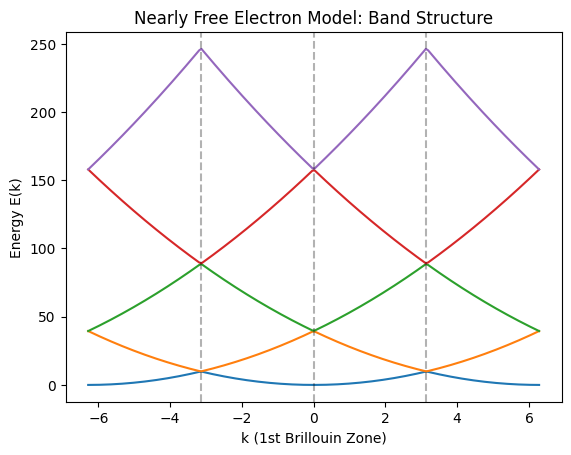

In [47]:

Plot_bands(N=11, V=[0])

# Potential Turned On

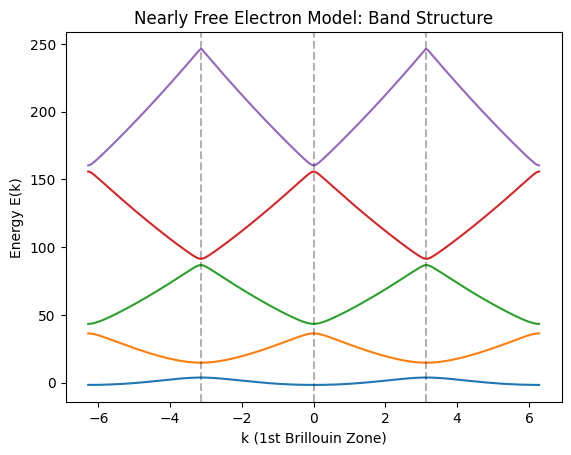

In [50]:
Plot_bands(N=11, V=[0, 6, 3, 2, 2])

###1) Since the bands go from increasing to decreasing as a function of k at pi, by Mean Value Theorem the slope has to be zero at pi

###2) We can clearly see that the nth band splitting is directly proportional to the nth harmonics